# contact_intelligence

pip install pandas numpy matplotlib seaborn

pip install scikit-learn

pip install torch torchvision torchaudio

pip install transformers datasets accelerate evaluate

pip install spacy

pip install sentencepiece

pip install jupyter

pip install notebook

pip install fastapi uvicorn

pip install pdfplumber

pip install pytesseract

pip install pdf2image

need to be install

<!-- pip install pandas numpy matplotlib seaborn
pip install scikit-learn
pip install torch torchvision torchaudio
pip install transformers datasets accelerate evaluate
pip install spacy
pip install sentencepiece
pip install jupyter
pip install notebook
pip install fastapi uvicorn
pip install pdfplumber
pip install pytesseract
pip install pdf2image -->

In [24]:


import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [25]:
from transformers import (

    AutoTokenizer,

    AutoModelForSequenceClassification,

    Trainer,

    TrainingArguments

)

print("Transformers Imported Successfully")

Transformers Imported Successfully


# Check Device

In [26]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


# Read Both CSV Files

In [27]:
clause_dataset = pd.read_csv("clauses.csv")       # 12679 rows
contract_dataset = pd.read_csv("contracts.csv")   # 510 rows
print("Datasets Loaded Successfully") 


Datasets Loaded Successfully


# Check Dataset

In [28]:
print(clause_dataset.shape)
print(contract_dataset.shape)

(12679, 5)
(510, 83)


In [29]:
display(clause_dataset.head())

,clause_text,clause_type,risk_level,cleaned_text,source_doc
0,DISTRIBUTOR AGREEMENT,Document Name,Low,distributor agreement,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...
1,Distributor,Parties,Low,distributor,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...
2,Electric City Corp.,Parties,Low,electric city corp.,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...
3,Electric City of Illinois L.L.C.,Parties,Low,electric city of illinois l.l.c.,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...
4,Company,Parties,Low,company,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...


In [30]:
display(contract_dataset.head())

,Filename,Document Name,Document Name-Answer,Parties,Parties-Answer,Agreement Date,Agreement Date-Answer,Effective Date,Effective Date-Answer,Expiration Date,...,Liquidated Damages,Liquidated Damages-Answer,Warranty Duration,Warranty Duration-Answer,Insurance,Insurance-Answer,Covenant Not To Sue,Covenant Not To Sue-Answer,Third Party Beneficiary,Third Party Beneficiary-Answer
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,['MARKETING AFFILIATE AGREEMENT'],MARKETING AFFILIATE AGREEMENT,"['BIRCH FIRST GLOBAL INVESTMENTS INC.', 'MA', ...","Birch First Global Investments Inc. (""Company""...","['8th day of May 2014', 'May 8, 2014']",5/8/14,['This agreement shall begin upon the date of ...,NaN,['This agreement shall begin upon the date of ...,...,[],No,"[""COMPANY'S SOLE AND EXCLUSIVE LIABILITY FOR T...",Yes,[],No,[],No,[],No
1,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B...,['VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT'],VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT,"['EuroMedia Holdings Corp.', 'Rogers', 'Rogers...","Rogers Cable Communications Inc. (""Rogers""); E...","['July 11 , 2006']",7/11/06,"['July 11 , 2006']",7/11/06,"['The term of this Agreement (the ""Initial Ter...",...,[],No,[],No,[],No,[],No,[],No
2,FulucaiProductionsLtd_20131223_10-Q_EX-10.9_83...,['CONTENT DISTRIBUTION AND LICENSE AGREEMENT'],CONTENT DISTRIBUTION AND LICENSE AGREEMENT,"['Producer', 'Fulucai Productions Ltd.', 'Conv...","CONVERGTV, INC. (“ConvergTV”); Fulucai Product...","['November 15, 2012']",11/15/12,"['November 15, 2012']",11/15/12,[],...,[],No,[],No,[],No,[],No,[],No
3,GopageCorp_20140221_10-K_EX-10.1_8432966_EX-10...,['WEBSITE CONTENT LICENSE AGREEMENT'],WEBSITE CONTENT LICENSE AGREEMENT,"['PSiTech Corporation', 'Licensor', 'Licensee'...","PSiTech Corporation (""Licensor""); Empirical Ve...","['Feb 10, 2014']",2/10/14,"['Feb 10, 2014']",2/10/14,['The initial term of this Agreement commences...,...,[],No,[],No,[],No,[],No,[],No
4,IdeanomicsInc_20160330_10-K_EX-10.26_9512211_E...,['CONTENT LICENSE AGREEMENT'],CONTENT LICENSE AGREEMENT,"['YOU ON DEMAND HOLDINGS, INC.', 'Licensor', '...",Beijing Sun Seven Stars Culture Development Li...,"['December 21, 2015']",12/21/15,"['December 21, 2015']",12/21/15,"['The Term of this Agreement (the ""Term"") shal...",...,[],No,[],No,[],No,[],No,[],No


# Check Missing Values

In [34]:
print(clause_dataset.isnull().sum())

clause_text      0
clause_type      0
risk_level       0
cleaned_text    13
source_doc       0
dtype: int64


In [35]:
print(contract_dataset.isnull().sum())

Filename                          0
Document Name                     0
Document Name-Answer              0
Parties                           0
Parties-Answer                    1
                                 ..
Insurance-Answer                  0
Covenant Not To Sue               0
Covenant Not To Sue-Answer        0
Third Party Beneficiary           0
Third Party Beneficiary-Answer    0
Length: 83, dtype: int64


# Duplicate Values

In [36]:
print(clause_dataset.duplicated().sum())

0


In [37]:
print(contract_dataset.duplicated().sum())

0


# Dataset Information

In [38]:
clause_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 12679 entries, 0 to 12678
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   clause_text   12679 non-null  str  
 1   clause_type   12679 non-null  str  
 2   risk_level    12679 non-null  str  
 3   cleaned_text  12666 non-null  str  
 4   source_doc    12679 non-null  str  
dtypes: str(5)
memory usage: 7.5 MB


In [39]:
contract_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 83 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Filename                                    510 non-null    str  
 1   Document Name                               510 non-null    str  
 2   Document Name-Answer                        510 non-null    str  
 3   Parties                                     510 non-null    str  
 4   Parties-Answer                              509 non-null    str  
 5   Agreement Date                              510 non-null    str  
 6   Agreement Date-Answer                       465 non-null    str  
 7   Effective Date                              510 non-null    str  
 8   Effective Date-Answer                       359 non-null    str  
 9   Expiration Date                             510 non-null    str  
 10  Expiration Date-Answer                      329 n

# Clause Distribution

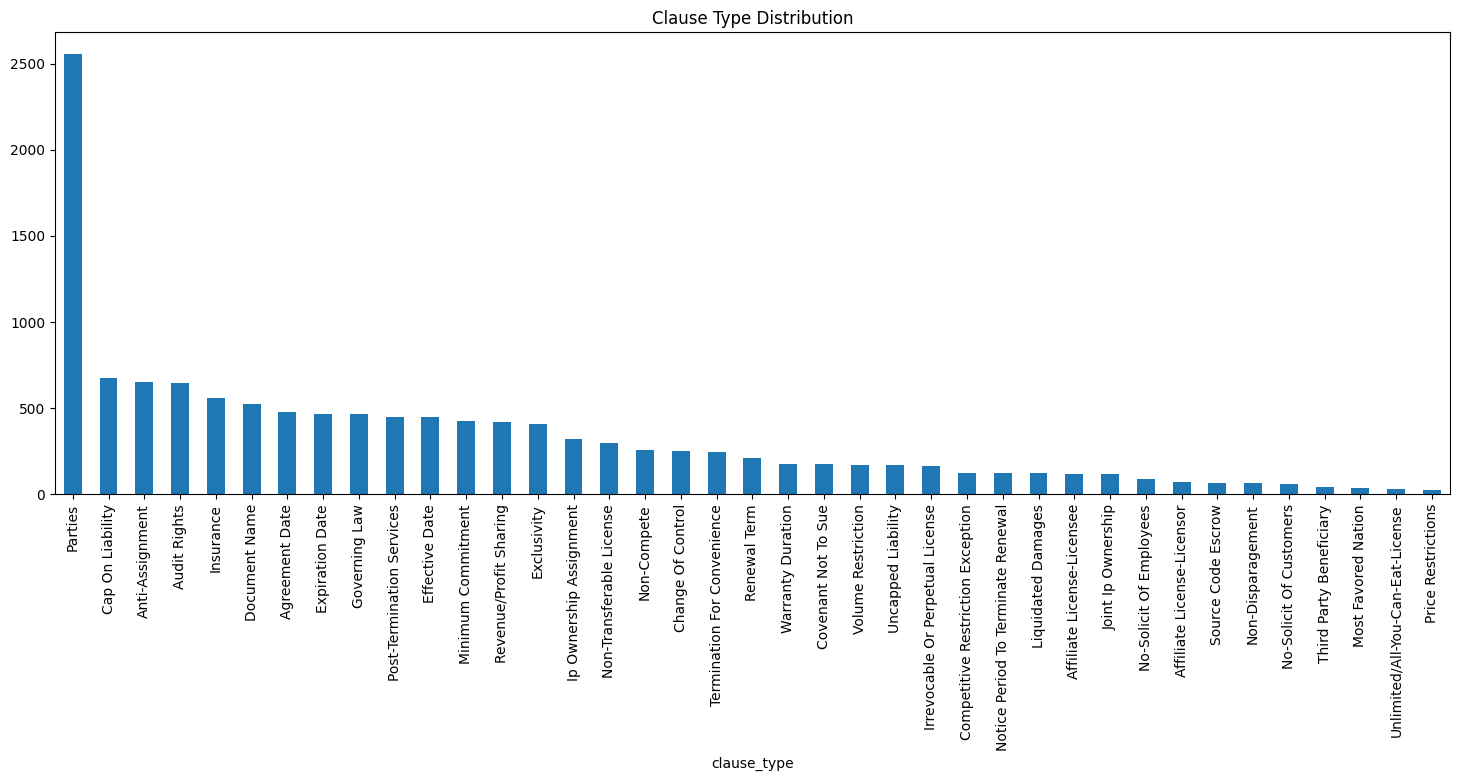

In [41]:
plt.figure(figsize=(18,6))

clause_dataset["clause_type"].value_counts().plot(
    kind="bar"
)

plt.title("Clause Type Distribution")

plt.xticks(rotation=90)

plt.show()

# Risk Distribution

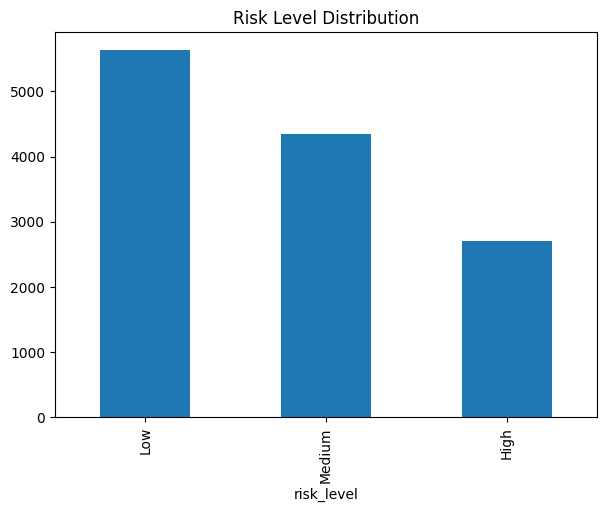

In [42]:
plt.figure(figsize=(7,5))

clause_dataset["risk_level"].value_counts().plot(
    kind="bar"
)

plt.title("Risk Level Distribution")

plt.show()

In [43]:
clause_dataset = clause_dataset[
    [
        "clause_text",
        "clause_type"
    ]
]

display(clause_dataset.head())

,clause_text,clause_type
0,DISTRIBUTOR AGREEMENT,Document Name
1,Distributor,Parties
2,Electric City Corp.,Parties
3,Electric City of Illinois L.L.C.,Parties
4,Company,Parties


# Drop Missing Values

In [44]:
clause_dataset.dropna(inplace=True)

clause_dataset.reset_index(
    drop=True,
    inplace=True
)

print(clause_dataset.shape)

(12679, 2)


# Remove Duplicates

In [45]:
clause_dataset.drop_duplicates(inplace=True)

clause_dataset.reset_index(
    drop=True,
    inplace=True
)

print(clause_dataset.shape)

(11969, 2)


# Label Encoding

In [46]:
label_encoder = LabelEncoder()

clause_dataset["label"] = label_encoder.fit_transform(
    clause_dataset["clause_type"]
)

display(clause_dataset.head())

,clause_text,clause_type,label
0,DISTRIBUTOR AGREEMENT,Document Name,9
1,Distributor,Parties,27
2,Electric City Corp.,Parties,27
3,Electric City of Illinois L.L.C.,Parties,27
4,Company,Parties,27


In [47]:
print(label_encoder.classes_)

['Affiliate License-Licensee' 'Affiliate License-Licensor'
 'Agreement Date' 'Anti-Assignment' 'Audit Rights' 'Cap On Liability'
 'Change Of Control' 'Competitive Restriction Exception'
 'Covenant Not To Sue' 'Document Name' 'Effective Date' 'Exclusivity'
 'Expiration Date' 'Governing Law' 'Insurance' 'Ip Ownership Assignment'
 'Irrevocable Or Perpetual License' 'Joint Ip Ownership'
 'Liquidated Damages' 'Minimum Commitment' 'Most Favored Nation'
 'No-Solicit Of Customers' 'No-Solicit Of Employees' 'Non-Compete'
 'Non-Disparagement' 'Non-Transferable License'
 'Notice Period To Terminate Renewal' 'Parties'
 'Post-Termination Services' 'Price Restrictions' 'Renewal Term'
 'Revenue/Profit Sharing' 'Source Code Escrow'
 'Termination For Convenience' 'Third Party Beneficiary'
 'Uncapped Liability' 'Unlimited/All-You-Can-Eat-License'
 'Volume Restriction' 'Warranty Duration']


In [48]:
print(len(label_encoder.classes_))

39


# Train Test Split

In [50]:
train_texts, test_texts, train_labels, test_labels = train_test_split(

    clause_dataset["clause_text"],

    clause_dataset["label"],

    test_size=0.20,

    random_state=42,

    stratify=clause_dataset["label"]

)

In [51]:
print(len(train_texts))

print(len(test_texts))

9575
2394


In [40]:
clause_dataset.columns

Index(['clause_text', 'clause_type', 'risk_level', 'cleaned_text',
       'source_doc'],
      dtype='str')

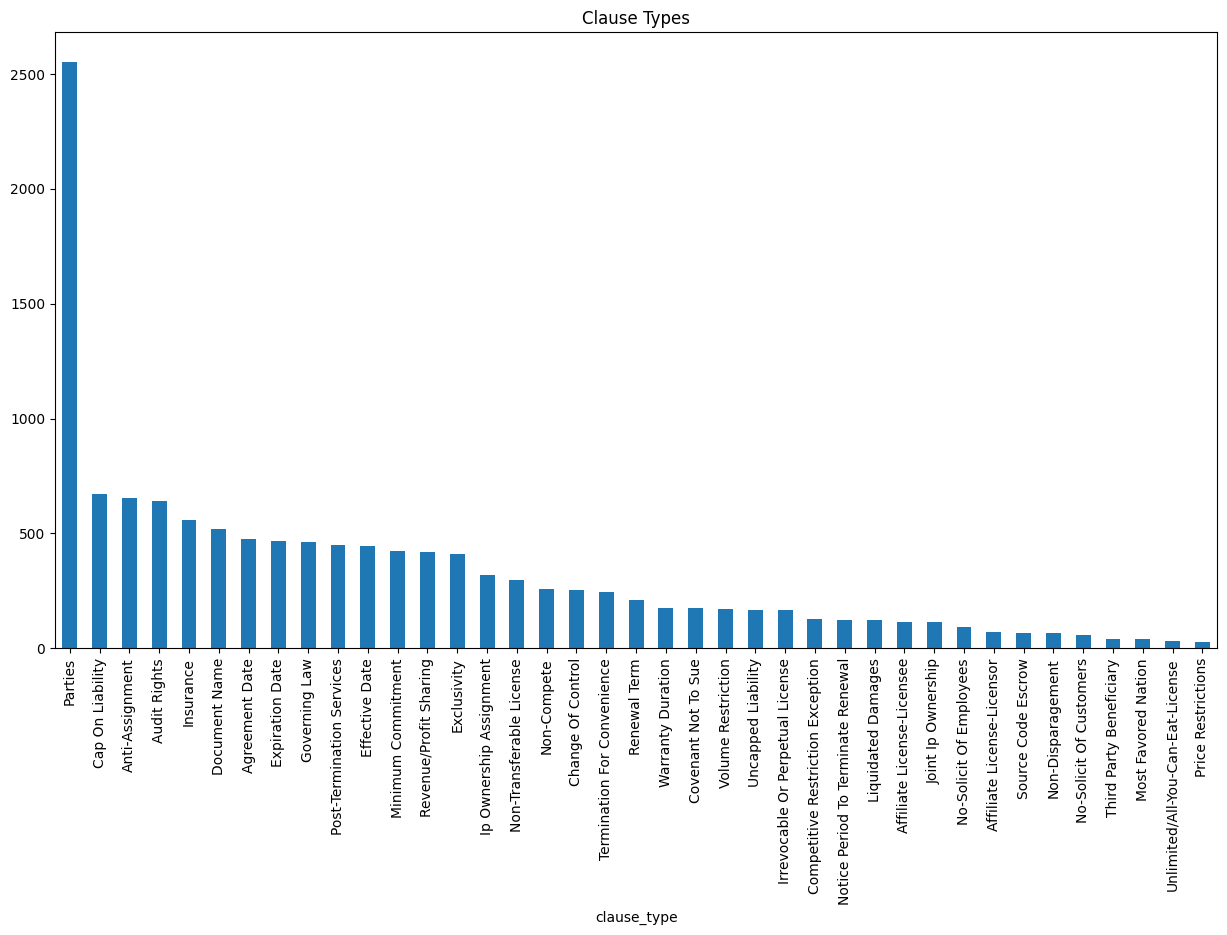

In [23]:
clause_dataset["clause_type"].value_counts().plot(
    kind="bar",
    figsize=(15,8)
)

plt.title("Clause Types")
plt.show()

In [57]:
import pandas as pd


In [58]:
contract_dataset = pd.read_csv("contracts.csv")
clause_dataset = pd.read_csv("clauses.csv")

In [59]:
print(contract_dataset.shape)
print(clause_dataset.shape)

print(clause_dataset.columns.tolist())

(12679, 5)
(510, 83)
['Filename', 'Document Name', 'Document Name-Answer', 'Parties', 'Parties-Answer', 'Agreement Date', 'Agreement Date-Answer', 'Effective Date', 'Effective Date-Answer', 'Expiration Date', 'Expiration Date-Answer', 'Renewal Term', 'Renewal Term-Answer', 'Notice Period To Terminate Renewal', 'Notice Period To Terminate Renewal- Answer', 'Governing Law', 'Governing Law-Answer', 'Most Favored Nation', 'Most Favored Nation-Answer', 'Competitive Restriction Exception', 'Competitive Restriction Exception-Answer', 'Non-Compete', 'Non-Compete-Answer', 'Exclusivity', 'Exclusivity-Answer', 'No-Solicit Of Customers', 'No-Solicit Of Customers-Answer', 'No-Solicit Of Employees', 'No-Solicit Of Employees-Answer', 'Non-Disparagement', 'Non-Disparagement-Answer', 'Termination For Convenience', 'Termination For Convenience-Answer', 'Rofr/Rofo/Rofn', 'Rofr/Rofo/Rofn-Answer', 'Change Of Control', 'Change Of Control-Answer', 'Anti-Assignment', 'Anti-Assignment-Answer', 'Revenue/Profit 

In [62]:
print(contract_dataset.shape)

print(clause_dataset.shape)

print(clause_dataset.columns.tolist())


(12679, 5)
(510, 83)
['Filename', 'Document Name', 'Document Name-Answer', 'Parties', 'Parties-Answer', 'Agreement Date', 'Agreement Date-Answer', 'Effective Date', 'Effective Date-Answer', 'Expiration Date', 'Expiration Date-Answer', 'Renewal Term', 'Renewal Term-Answer', 'Notice Period To Terminate Renewal', 'Notice Period To Terminate Renewal- Answer', 'Governing Law', 'Governing Law-Answer', 'Most Favored Nation', 'Most Favored Nation-Answer', 'Competitive Restriction Exception', 'Competitive Restriction Exception-Answer', 'Non-Compete', 'Non-Compete-Answer', 'Exclusivity', 'Exclusivity-Answer', 'No-Solicit Of Customers', 'No-Solicit Of Customers-Answer', 'No-Solicit Of Employees', 'No-Solicit Of Employees-Answer', 'Non-Disparagement', 'Non-Disparagement-Answer', 'Termination For Convenience', 'Termination For Convenience-Answer', 'Rofr/Rofo/Rofn', 'Rofr/Rofo/Rofn-Answer', 'Change Of Control', 'Change Of Control-Answer', 'Anti-Assignment', 'Anti-Assignment-Answer', 'Revenue/Profit 